### Convergence Study Stuff

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
CSV_PATH = "convergence_results.csv"  # change if needed
SAVE_DIR = "Figures"                           # set to None to disable saving
DPI = 200

if SAVE_DIR is not None:
    os.makedirs(SAVE_DIR, exist_ok=True)



plt.rcParams.update({
    "figure.figsize": (7.5, 5.0),
    "axes.grid": True,
    "grid.alpha": 0.3,
    "axes.titlesize": 13,
    "axes.labelsize": 12,
    "legend.fontsize": 10,
})

In [3]:
# Cell 2 — load + quick sanity checks
df = pd.read_csv(CSV_PATH)

# Exclude schemes from analysis
exclude_schemes = ["WENO5z"]
df = df[~df["scheme"].isin(exclude_schemes)].copy()

required = {"scheme","nx","ny","h","L1_rho","L2_rho","Linf_rho","wall_s"}
missing = required - set(df.columns)
if missing:
    raise ValueError(f"CSV missing required columns: {missing}")

# keep only square grids (optional safety)
df = df[df["nx"] == df["ny"]].copy()

# sort for consistent plotting / order calc
df.sort_values(["scheme", "h"], ascending=[True, False], inplace=True)

display(df.head(10))
print("Schemes:", sorted(df["scheme"].unique()))
print("Resolutions:", sorted(df["nx"].unique()))




,scheme,nx,ny,h,CFL,t_end,steps,dt_mean,wall_s,L1_rho,L2_rho,Linf_rho
0,FirstOrder,64,64,0.015625,0.1,0.1,157,0.000637,0.307962,9.130268e-03,1.127771e-02,2.371041e-02
1,FirstOrder,128,128,0.007812,0.1,0.1,313,0.000319,2.482202,4.699483e-03,5.806565e-03,1.230258e-02
2,FirstOrder,256,256,0.003906,0.1,0.1,625,0.000160,21.481070,2.383700e-03,2.946037e-03,6.269904e-03
3,FirstOrder,512,512,0.001953,0.1,0.1,1250,0.000080,139.019996,1.200411e-03,1.483809e-03,3.165473e-03
16,TENO5,64,64,0.015625,0.1,0.1,157,0.000637,3.631071,3.024615e-08,3.737795e-08,7.983904e-08
17,TENO5,128,128,0.007812,0.1,0.1,313,0.000319,23.975150,9.833543e-10,1.212011e-09,2.581571e-09
18,TENO5,256,256,0.003906,0.1,0.1,625,0.000160,181.612545,3.592945e-11,4.347886e-11,9.091461e-11
19,TENO5,512,512,0.001953,0.1,0.1,1250,0.000080,1451.009235,1.870535e-12,2.154647e-12,4.051426e-12
4,WENO3,64,64,0.015625,0.1,0.1,157,0.000637,0.531931,5.064779e-04,8.523514e-04,5.462404e-03
5,WENO3,128,128,0.007812,0.1,0.1,313,0.000319,4.303144,7.157792e-05,1.165606e-04,1.017287e-03


Schemes: ['FirstOrder', 'TENO5', 'WENO3', 'WENO5', 'WENO5Z']
Resolutions: [64, 128, 256, 512]


In [4]:
# Cell 3 — helper functions: observed order + log-fit slope
def observed_orders(sub: pd.DataFrame, err_col: str) -> pd.DataFrame:
    """
    Compute observed order p between successive refinements:
        p = log(e_coarse/e_fine) / log(h_coarse/h_fine)
    Returns a table with per-pair p values.
    """
    s = sub.sort_values("h", ascending=False).reset_index(drop=True)
    h = s["h"].to_numpy()
    e = s[err_col].to_numpy()

    p = np.log(e[:-1] / e[1:]) / np.log(h[:-1] / h[1:])
    out = pd.DataFrame({
        "nx_coarse": s["nx"].iloc[:-1].to_numpy(),
        "nx_fine":   s["nx"].iloc[1:].to_numpy(),
        "h_coarse":  h[:-1],
        "h_fine":    h[1:],
        f"p_{err_col}": p
    })
    return out

def loglog_fit_slope(h: np.ndarray, e: np.ndarray) -> float:
    """
    Fit slope in log10 space: log10(e) = a + p*log10(h) => p is the observed order.
    """
    x = np.log10(h)
    y = np.log10(e)
    p, a = np.polyfit(x, y, 1)  # slope p
    return p


In [5]:
# Cell 4 — compute order tables + summary (per scheme)
err_cols = ["L1_rho", "L2_rho", "Linf_rho"]

order_rows = []
pairwise_tables = {}

for scheme, sub in df.groupby("scheme"):
    pairwise_tables[scheme] = {}
    for col in err_cols:
        pw = observed_orders(sub, col)
        pairwise_tables[scheme][col] = pw

        # a single number summary: average over refinement pairs
        p_mean = pw[f"p_{col}"].mean()
        p_min  = pw[f"p_{col}"].min()
        p_max  = pw[f"p_{col}"].max()
        order_rows.append({"scheme": scheme, "norm": col, "p_mean": p_mean, "p_min": p_min, "p_max": p_max})

order_summary = pd.DataFrame(order_rows).sort_values(["norm","scheme"])
display(order_summary)


,scheme,norm,p_mean,p_min,p_max
0,FirstOrder,L1_rho,0.975709,0.958155,0.989674
3,TENO5,L1_rho,4.660338,4.263644,4.942896
6,WENO3,L1_rho,2.615181,2.168311,2.854319
9,WENO5,L1_rho,5.039881,5.020644,5.051969
12,WENO5Z,L1_rho,4.660333,4.263631,4.942897
1,FirstOrder,L2_rho,0.975365,0.957717,0.989470
4,TENO5,L2_rho,4.694149,4.334791,4.946713
7,WENO3,L2_rho,2.815998,2.252639,3.324986
10,WENO5,L2_rho,5.054998,5.025934,5.090897
13,WENO5Z,L2_rho,4.694163,4.334783,4.946759


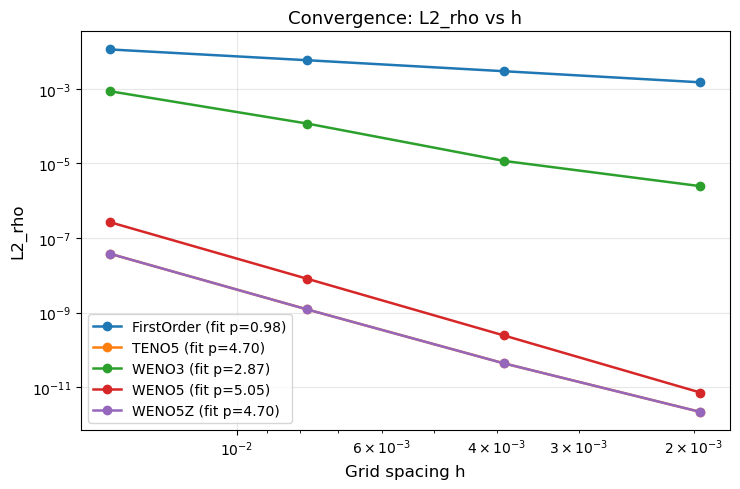

In [6]:
# Cell 5 — Plot 1: error vs h (log-log), with fitted slope per scheme
norm_to_plot = "L2_rho"  # change to "L1_rho" or "Linf_rho" if you want

fig = plt.figure()
for scheme, sub in df.groupby("scheme"):
    sub = sub.sort_values("h", ascending=False)
    h = sub["h"].to_numpy()
    e = sub[norm_to_plot].to_numpy()

    # slope fit across all points
    p_fit = loglog_fit_slope(h, e)

    plt.loglog(h, e, marker="o", linewidth=1.8, label=f"{scheme} (fit p={p_fit:.2f})")

plt.gca().invert_xaxis()  # finer grids to the right is often nicer; flip if you prefer
plt.xlabel("Grid spacing h")
plt.ylabel(norm_to_plot)
plt.title(f"Convergence: {norm_to_plot} vs h")
plt.legend()

plt.tight_layout()
if SAVE_DIR is not None:
    out = os.path.join(SAVE_DIR, f"convergence_{norm_to_plot}.png")
    plt.savefig(out, dpi=DPI)
plt.show()




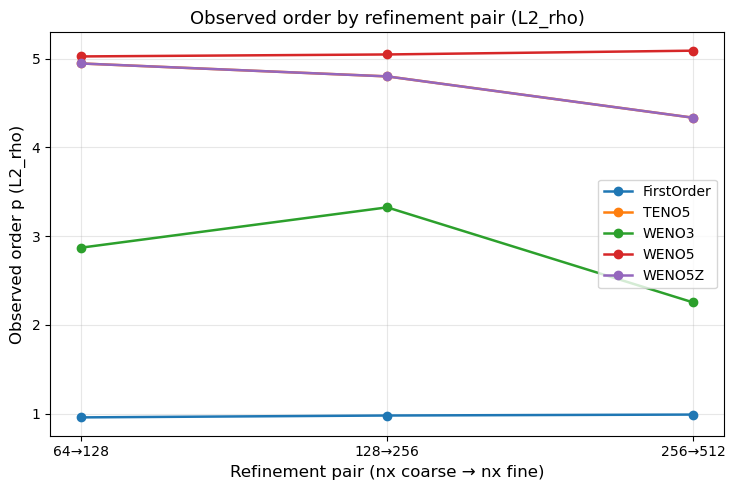

In [29]:
# Cell 6 — Plot 2: observed order per refinement (pairwise), per scheme
norm_to_plot = "L2_rho"

fig = plt.figure()
for scheme in sorted(df["scheme"].unique()):
    pw = pairwise_tables[scheme][norm_to_plot]
    xs = np.arange(len(pw))  # pairs
    plt.plot(xs, pw[f"p_{norm_to_plot}"], marker="o", linewidth=1.8, label=scheme)

plt.xticks(
    ticks=np.arange(0, len(pw)),
    labels=[f"{int(a)}→{int(b)}" for a, b in zip(pw["nx_coarse"], pw["nx_fine"])]
)
plt.xlabel("Refinement pair (nx coarse → nx fine)")
plt.ylabel(f"Observed order p ({norm_to_plot})")
plt.title(f"Observed order by refinement pair ({norm_to_plot})")
plt.legend()
plt.tight_layout()

if SAVE_DIR is not None:
    out = os.path.join(SAVE_DIR, f"orders_pairs_{norm_to_plot}.png")
    plt.savefig(out, dpi=DPI)
plt.show()


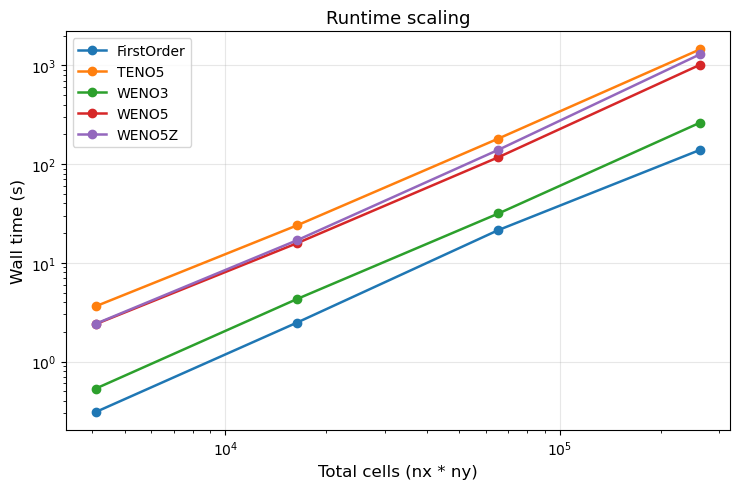

In [30]:
# Cell 7 — Plot 3: wall time scaling (log-log) vs total cells (nx*ny)
fig = plt.figure()
for scheme, sub in df.groupby("scheme"):
    sub = sub.sort_values("nx")
    cells = (sub["nx"] * sub["ny"]).to_numpy()
    wall = sub["wall_s"].to_numpy()

    plt.loglog(cells, wall, marker="o", linewidth=1.8, label=scheme)

plt.xlabel("Total cells (nx * ny)")
plt.ylabel("Wall time (s)")
plt.title("Runtime scaling")
plt.legend()
plt.tight_layout()

if SAVE_DIR is not None:
    out = os.path.join(SAVE_DIR, "runtime_scaling.png")
    plt.savefig(out, dpi=DPI)
plt.show()


In [31]:
# Cell 8 — optional: nice table to paste into a report (mean/min/max orders)
pivot = (
    order_summary
    .pivot(index="scheme", columns="norm", values="p_mean")
    .reindex(sorted(df["scheme"].unique()))
)

display(pivot.round(3))


norm,L1_rho,L2_rho,Linf_rho
scheme,,,
FirstOrder,0.976,0.975,0.968
TENO5,4.660,4.694,4.755
WENO3,2.615,2.816,3.477
WENO5,5.040,5.055,5.154
WENO5Z,4.660,4.694,4.755
